# KPIs Operacionais Portuários — Brasil 2025
**Fonte:** ANTAQ — Atracação, Tempos de Atracação, Paralisações  
**Escopo:** 116.098 atracações | 228.249 eventos de paralisação  
**Objetivo:** Diagnóstico de eficiência operacional: tempos de espera, operação, estadia e causas de paralisação

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths — ajuste se necessário
BASE = Path('../data')
OPS  = BASE / '02_Operacoes'
IND  = BASE / '03_Indicadores'
OUT  = Path('../outputs/figures')
OUT.mkdir(parents=True, exist_ok=True)

# Estilo
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

MES_ORDER = ['jan','fev','mar','abr','mai','jun','jul','ago','set','out','nov','dez']

## 1. Carga e Pré-processamento

In [2]:
# ── Atracação ──────────────────────────────────────────────────────────────────
atr = pd.read_csv(OPS / '2025_Atracacao.csv', sep=';', encoding='utf-8-sig', low_memory=False)

# Datas
for col in ['Data Atracação','Data Chegada','Data Desatracação',
            'Data Início Operação','Data Término Operação']:
    atr[col] = pd.to_datetime(atr[col], dayfirst=True, errors='coerce')

# Mês como categoria ordenada
atr['Mes'] = pd.Categorical(atr['Mes'], categories=MES_ORDER, ordered=True)

# ── Tempos ─────────────────────────────────────────────────────────────────────
t = pd.read_csv(IND / '2025_Tempos_Atracacao.csv', sep=';', encoding='utf-8-sig')
TEMPO_COLS = ['TEsperaAtracacao','TEsperaInicioOp','TOperacao',
              'TEsperaDesatracacao','TAtracado','TEstadia']
for col in TEMPO_COLS:
    t[col] = pd.to_numeric(t[col].astype(str).str.replace(',','.', regex=False), errors='coerce')

# ── Paralisação ────────────────────────────────────────────────────────────────
p = pd.read_csv(IND / '2025_Tempos_Atracacao_Paralisacao.csv', sep=';', encoding='utf-8-sig')
p['DTInicio']  = pd.to_datetime(p['DTInicio'],  dayfirst=True, errors='coerce')
p['DTTermino'] = pd.to_datetime(p['DTTermino'], dayfirst=True, errors='coerce')
p['Duracao_h'] = (p['DTTermino'] - p['DTInicio']).dt.total_seconds() / 3600
# Remover durações inválidas (negativas ou zero)
p = p[p['Duracao_h'] > 0].copy()

print(f'Atracações : {len(atr):,}')
print(f'Tempos     : {len(t):,}  |  Discrepantes/Zero removidos: {116098 - t["TEstadia"].notna().sum():,}')
print(f'Paralisações (eventos válidos): {len(p):,}')

Atracações : 116,098
Tempos     : 116,098  |  Discrepantes/Zero removidos: 2,245
Paralisações (eventos válidos): 225,618


## 2. Volume de Atracações 2025

### 2.1 Distribuição por Tipo de Navegação

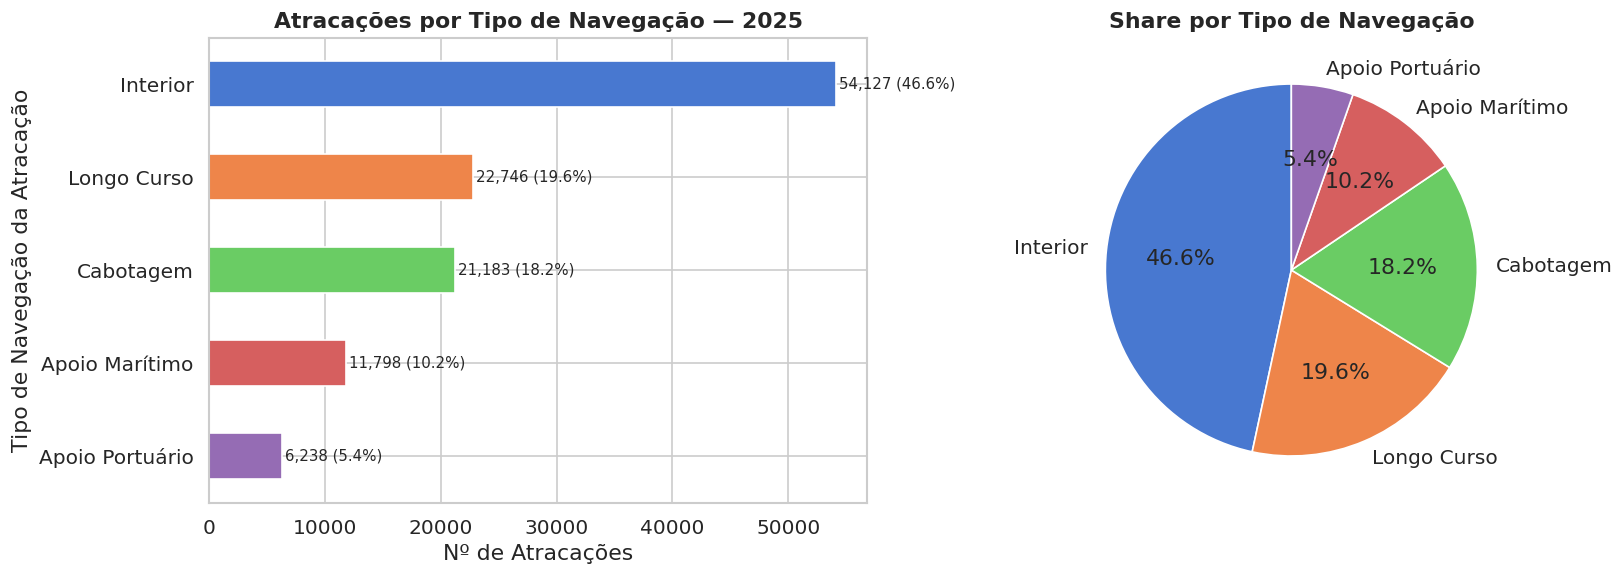


--- Tabela ---


,Atracações,Share (%)
Tipo de Navegação da Atracação,,
Interior,54127,46.6
Longo Curso,22746,19.6
Cabotagem,21183,18.2
Apoio Marítimo,11798,10.2
Apoio Portuário,6238,5.4


In [3]:
nav = atr['Tipo de Navegação da Atracação'].value_counts()
nav_pct = (nav / nav.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
nav.plot.barh(ax=axes[0], color=sns.color_palette('muted', len(nav)))
axes[0].set_title('Atracações por Tipo de Navegação — 2025', fontweight='bold')
axes[0].set_xlabel('Nº de Atracações')
axes[0].invert_yaxis()
for i, (v, pct) in enumerate(zip(nav.values, nav_pct.values)):
    axes[0].text(v + 300, i, f'{v:,} ({pct}%)', va='center', fontsize=9)

# Pie
axes[1].pie(nav.values, labels=nav.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(nav)), startangle=90)
axes[1].set_title('Share por Tipo de Navegação', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'nb08_01_tipo_navegacao.png', bbox_inches='tight')
plt.show()

print('\n--- Tabela ---')
pd.DataFrame({'Atracações': nav, 'Share (%)': nav_pct})

### 2.2 Evolução Mensal

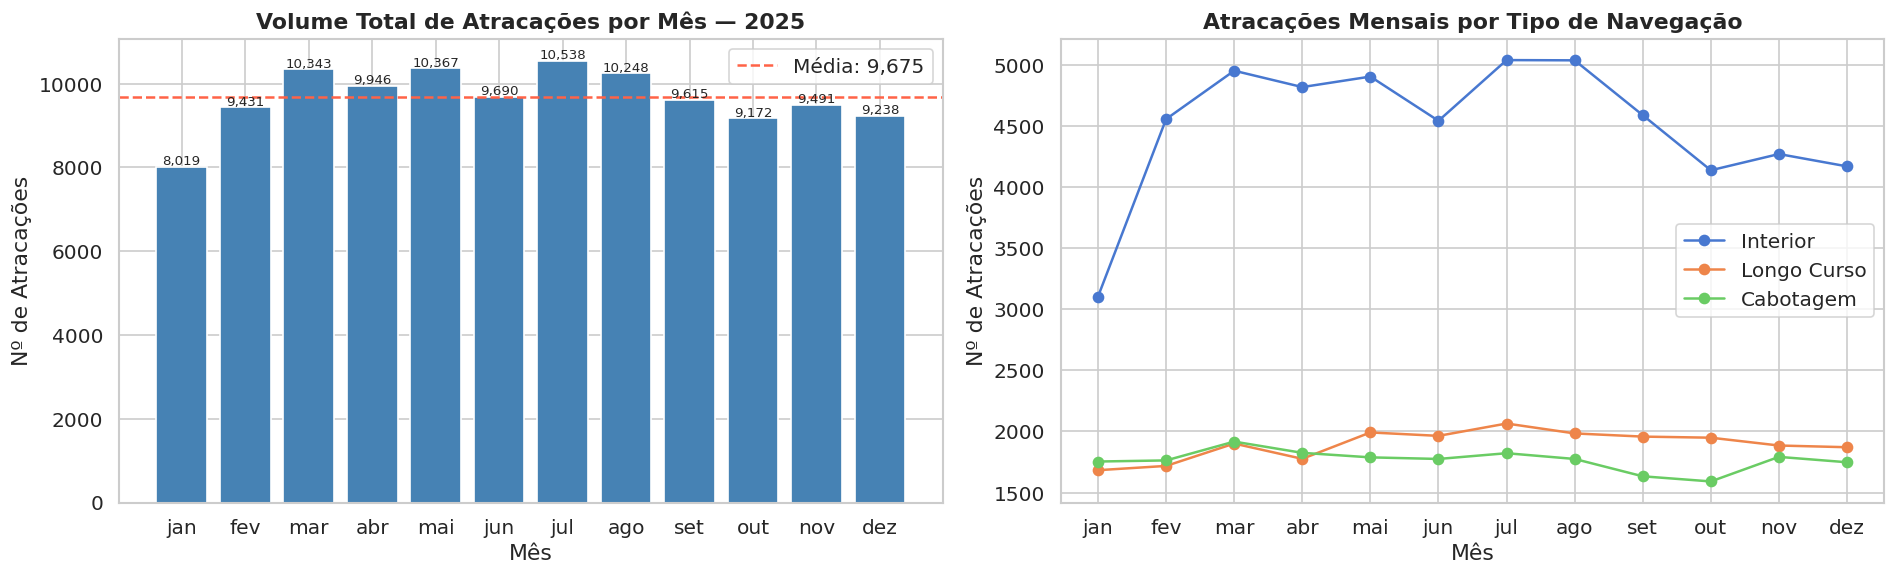

In [4]:
# Volume total por mês
mensal = atr.groupby('Mes', observed=True).size().reset_index(name='Atracações')

# Por tipo de navegação + mês (excluindo apoio)
nav_interesse = ['Interior','Longo Curso','Cabotagem']
mensal_nav = (
    atr[atr['Tipo de Navegação da Atracação'].isin(nav_interesse)]
    .groupby(['Mes','Tipo de Navegação da Atracação'], observed=True)
    .size()
    .reset_index(name='Atracações')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total mensal
axes[0].bar(mensal['Mes'].astype(str), mensal['Atracações'],
            color='steelblue', edgecolor='white')
axes[0].axhline(mensal['Atracações'].mean(), color='tomato', linestyle='--',
                label=f'Média: {mensal["Atracações"].mean():,.0f}')
axes[0].set_title('Volume Total de Atracações por Mês — 2025', fontweight='bold')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Nº de Atracações')
axes[0].legend()
for i, row in mensal.iterrows():
    axes[0].text(i, row['Atracações'] + 50, f"{row['Atracações']:,}",
                 ha='center', fontsize=8)

# Por tipo de navegação
for nav_tipo in nav_interesse:
    subset = mensal_nav[mensal_nav['Tipo de Navegação da Atracação'] == nav_tipo]
    axes[1].plot(subset['Mes'].astype(str), subset['Atracações'],
                 marker='o', label=nav_tipo)
axes[1].set_title('Atracações Mensais por Tipo de Navegação', fontweight='bold')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Nº de Atracações')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT / 'nb08_02_evolucao_mensal.png', bbox_inches='tight')
plt.show()

### 2.3 Top 15 Portos por Volume

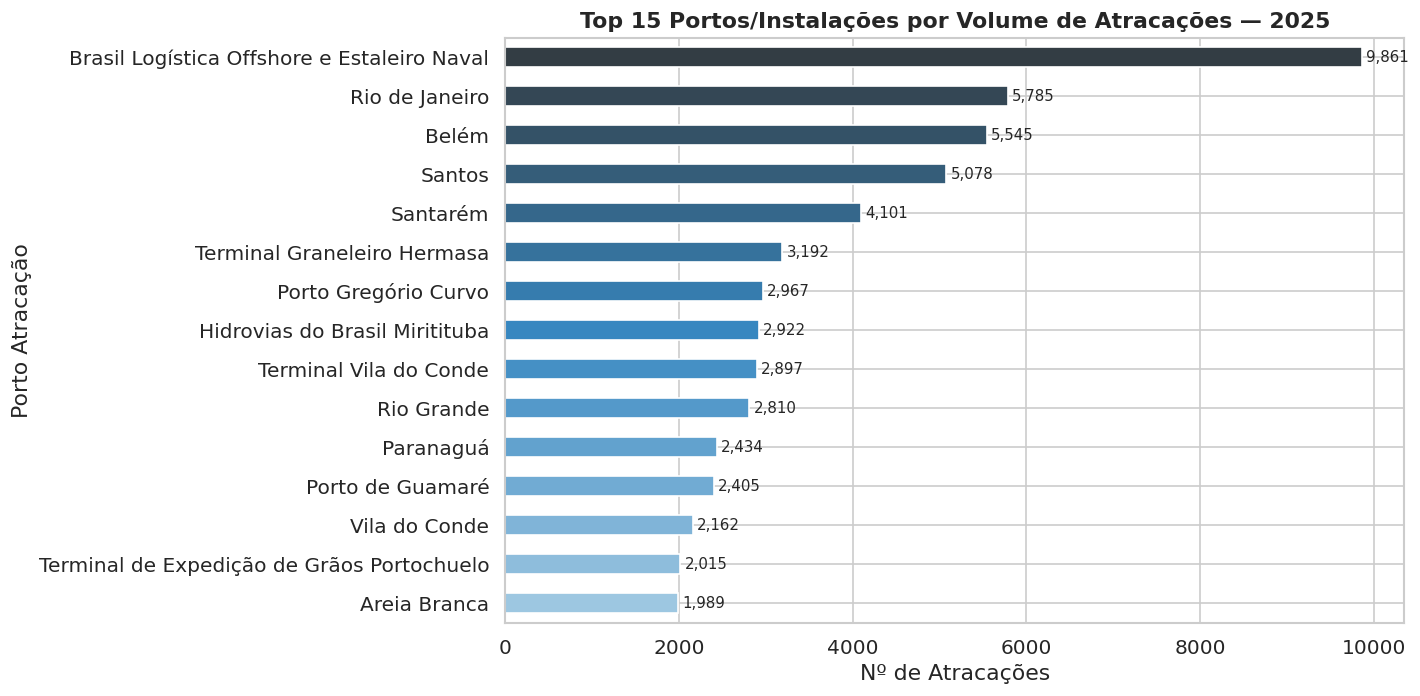


Atracações por UF:
UF           Pará  Rio de Janeiro  Amazonas  São Paulo  Rio Grande do Sul  Rondônia  Rio Grande do Norte  Mato Grosso do Sul  Espírito Santo  Santa Catarina  Paraná  Pernambuco  Maranhão  Bahia  Ceará  Goiás  Sergipe  Amapá  Alagoas  Paraíba
Atracações  28663           24760     12858       8180               7623      5641                 5561                3715            2926            2838    2808        2309      1979   1869   1612    854      754    691      367       84


In [5]:
top_portos = atr['Porto Atracação'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_portos.sort_values().plot.barh(ax=ax, color=sns.color_palette('Blues_d', 15))
ax.set_title('Top 15 Portos/Instalações por Volume de Atracações — 2025', fontweight='bold')
ax.set_xlabel('Nº de Atracações')
for i, v in enumerate(top_portos.sort_values().values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'nb08_03_top15_portos.png', bbox_inches='tight')
plt.show()

# Por UF
uf_vol = atr.groupby('UF').size().sort_values(ascending=False)
print('\nAtracações por UF:')
print(uf_vol.to_frame('Atracações').T.to_string())

### 2.4 Mix de Tipo de Operação por Tipo de Navegação

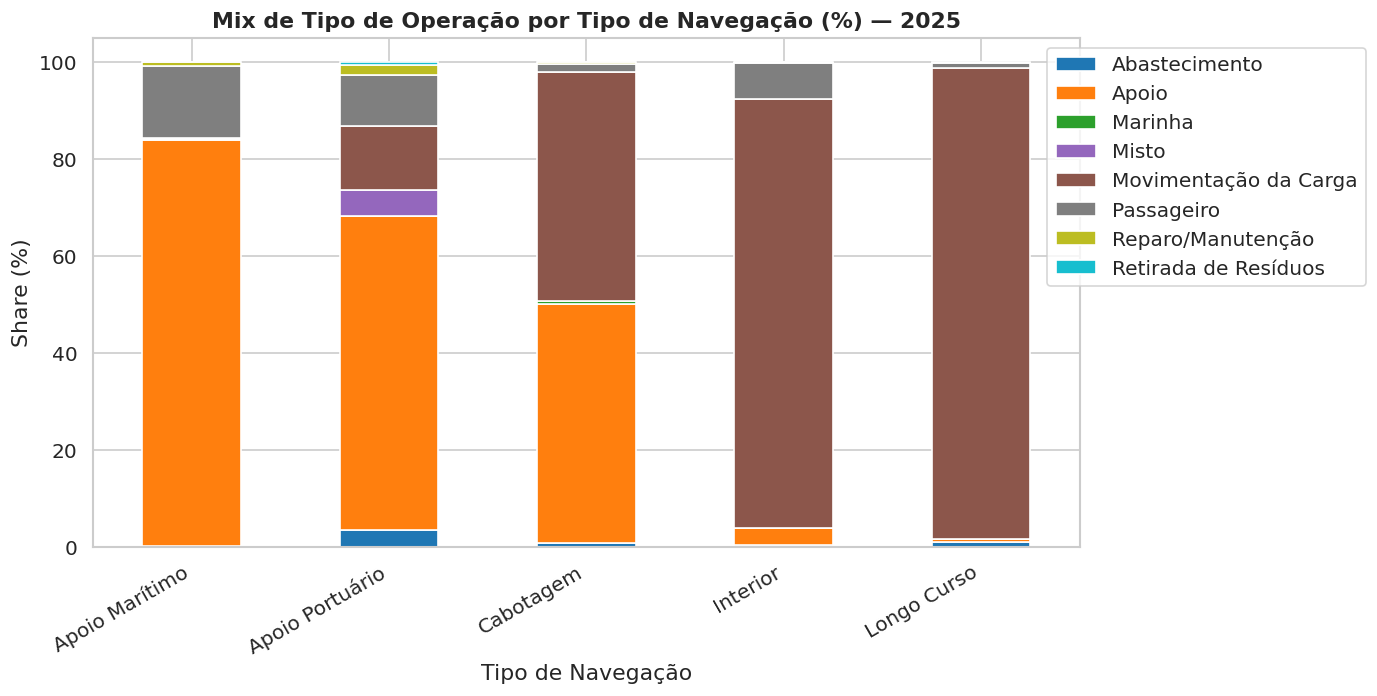

Tipo de Operação                Abastecimento  Apoio  Marinha  Misto  Movimentação da Carga  Passageiro  Reparo/Manutenção  Retirada de Resíduos
Tipo de Navegação da Atracação                                                                                                                  
Apoio Marítimo                            0.1   83.8      0.1    0.0                    0.2        14.9                0.8                   0.0
Apoio Portuário                           3.5   64.6      0.0    5.4                   13.2        10.5                2.1                   0.7
Cabotagem                                 0.9   49.2      0.6    0.0                   47.2         1.7                0.5                   0.0
Interior                                  0.3    3.5      0.0    0.0                   88.5         7.4                0.3                   0.0
Longo Curso                               0.9    0.6      0.1    0.0                   97.1         1.1                0.3        

In [6]:
op_nav = (
    atr.groupby(['Tipo de Navegação da Atracação','Tipo de Operação'])
    .size()
    .unstack(fill_value=0)
)
op_nav_pct = op_nav.div(op_nav.sum(axis=1), axis=0) * 100

op_nav_pct.plot.bar(stacked=True, figsize=(12, 6),
                    colormap='tab10', edgecolor='white')
plt.title('Mix de Tipo de Operação por Tipo de Navegação (%) — 2025', fontweight='bold')
plt.xlabel('Tipo de Navegação')
plt.ylabel('Share (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.savefig(OUT / 'nb08_04_mix_operacao.png', bbox_inches='tight')
plt.show()

print(op_nav_pct.round(1).to_string())

## 3. KPIs de Tempos Operacionais

### 3.1 Estatísticas Gerais (horas)

In [7]:
# Merge tempos com atracação
df = atr.merge(t, on='IDAtracacao', how='inner')
print(f'Merge: {len(df):,} atracações com tempos disponíveis')

# Estatísticas descritivas
labels = {
    'TEsperaAtracacao' : 'T. Espera Atracação (h)',
    'TEsperaInicioOp'  : 'T. Espera Início Op. (h)',
    'TOperacao'        : 'T. Operação (h)',
    'TEsperaDesatracacao': 'T. Espera Desatracação (h)',
    'TAtracado'        : 'T. Atracado (h)',
    'TEstadia'         : 'T. Estadia (h)'
}

stats = df[TEMPO_COLS].describe(percentiles=[.25,.5,.75,.9,.95]).T
stats.index = [labels.get(c, c) for c in stats.index]
stats.rename(columns={'50%':'Mediana','75%':'P75','90%':'P90','95%':'P95'}, inplace=True)
print('\nKPIs de Tempos — 2025 (horas)')
stats[['mean','Mediana','P75','P90','P95','max']].round(2)

Merge: 116,098 atracações com tempos disponíveis

KPIs de Tempos — 2025 (horas)


,mean,Mediana,P75,P90,P95,max
T. Espera Atracação (h),33.72,1.00,25.00,97.75,180.71,1832.87
T. Espera Início Op. (h),3.27,0.40,1.92,5.00,9.63,2036.92
T. Operação (h),18.27,6.75,19.03,48.68,79.22,893.00
T. Espera Desatracação (h),3.05,0.92,2.83,6.58,11.27,485.98
T. Atracado (h),24.91,10.83,27.40,64.59,97.37,2045.93
T. Estadia (h),59.16,19.67,63.15,159.38,254.00,2046.02


### 3.2 Distribuição dos Tempos Principais

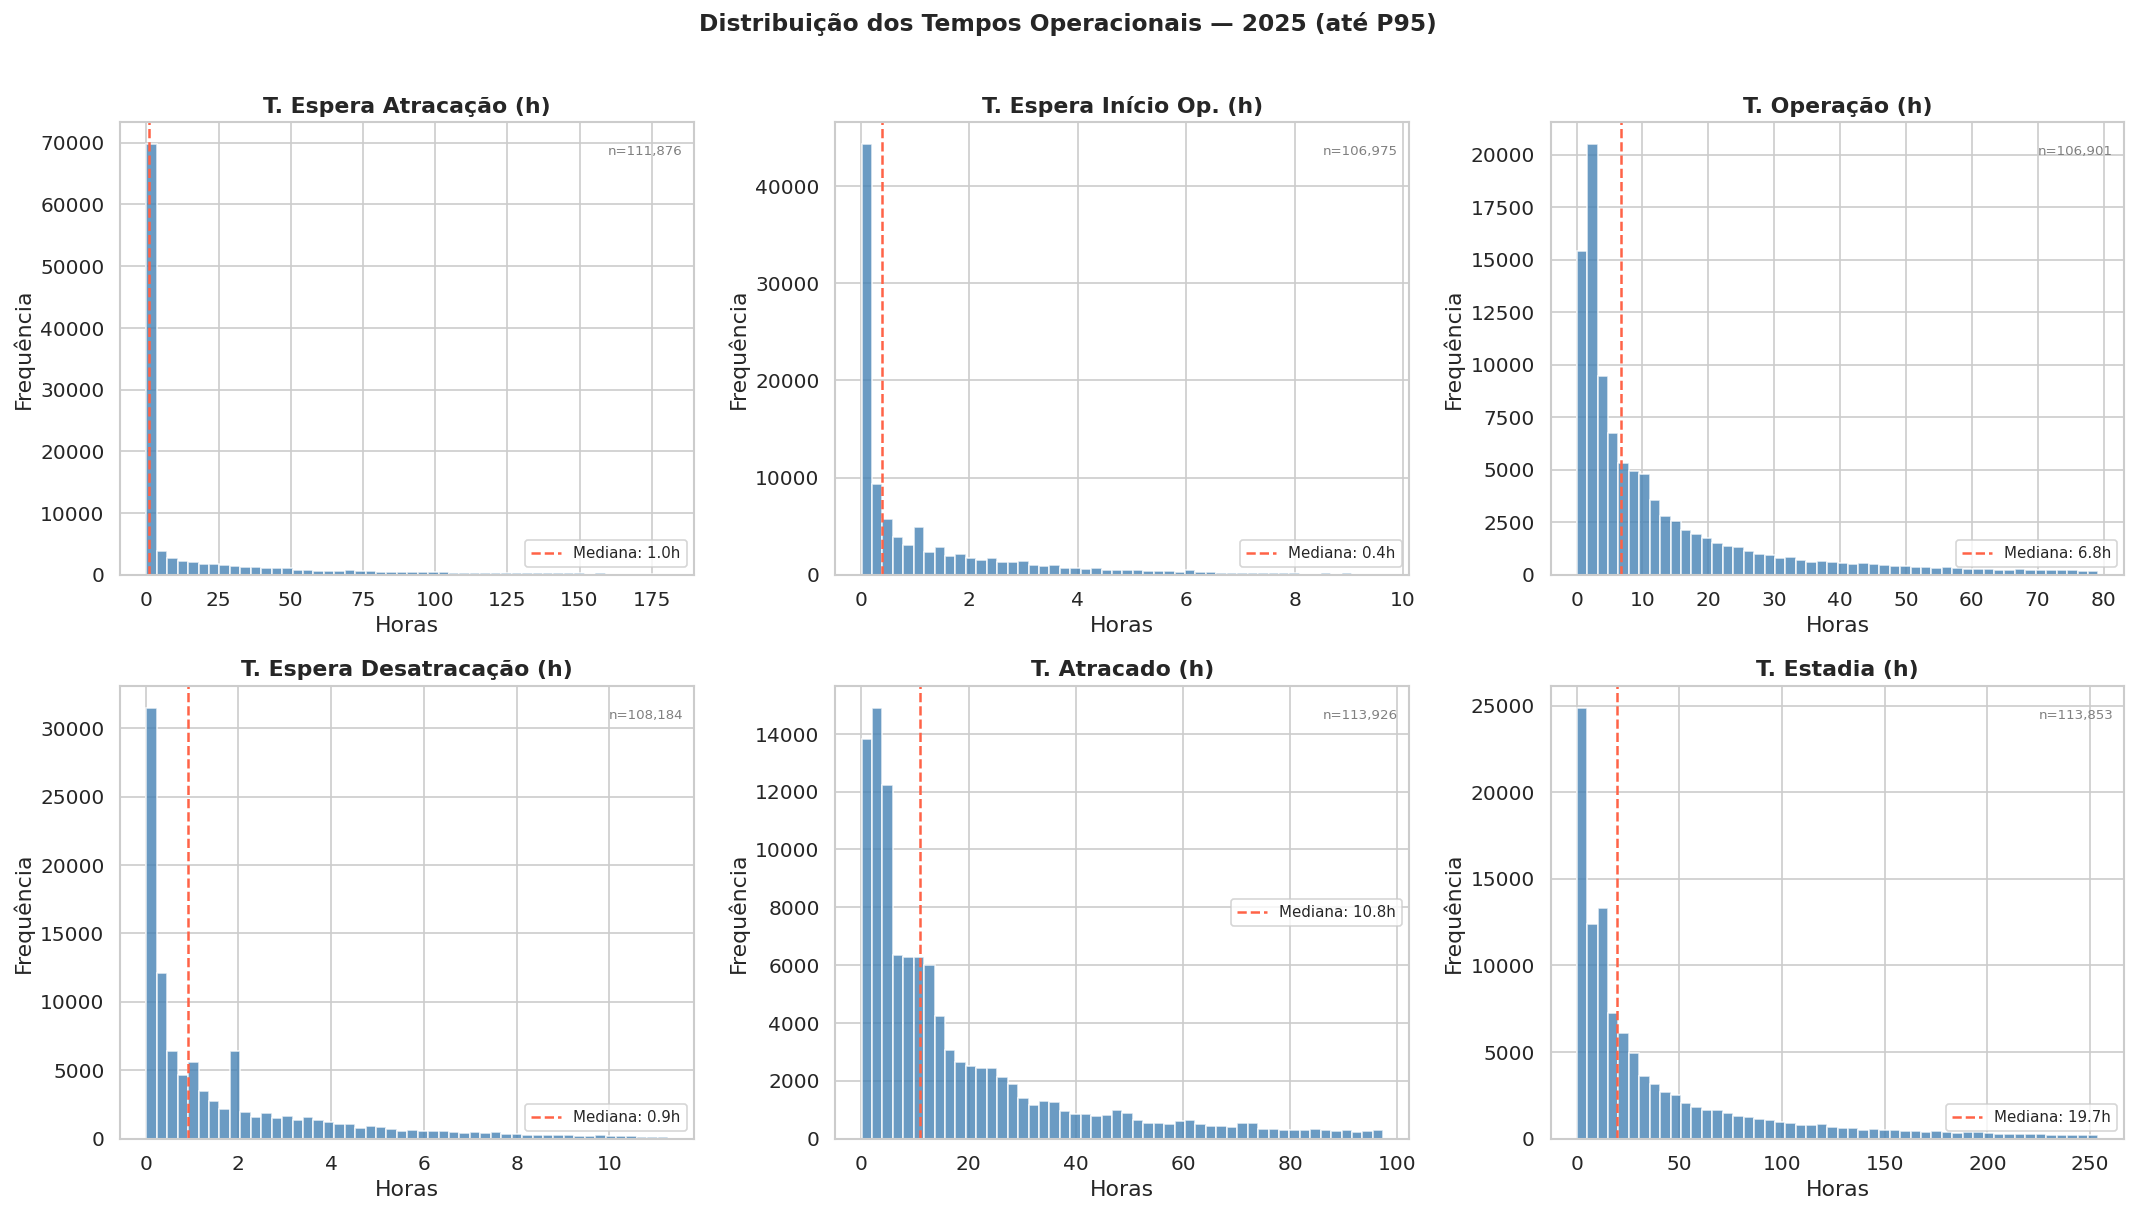

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(labels.items()):
    data = df[col].dropna()
    # Limita ao P95 para visualização limpa
    cap = data.quantile(0.95)
    data_viz = data[data <= cap]
    axes[i].hist(data_viz, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    med = data.median()
    axes[i].axvline(med, color='tomato', linestyle='--', label=f'Mediana: {med:.1f}h')
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_xlabel('Horas')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=9)
    axes[i].text(0.98, 0.95, f'n={len(data):,}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=8, color='gray')

plt.suptitle('Distribuição dos Tempos Operacionais — 2025 (até P95)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'nb08_05_distribuicao_tempos.png', bbox_inches='tight')
plt.show()

### 3.3 Tempos Medianos por Tipo de Navegação

Medianas (horas) por Tipo de Navegação:
                                T. Espera Atracação (h)  T. Espera Início Op. (h)  T. Operação (h)  T. Espera Desatracação (h)  T. Atracado (h)  T. Estadia (h)
Tipo de Navegação da Atracação                                                                                                                                 
Apoio Marítimo                                     1.00                      0.58             7.17                        0.17             9.33           16.17
Apoio Portuário                                    1.00                      0.08             3.50                        0.20             4.83            9.67
Cabotagem                                          1.00                      0.17            11.48                        1.58            15.25           17.58
Interior                                           0.25                      0.17             2.88                        0.37             4.62           12.33


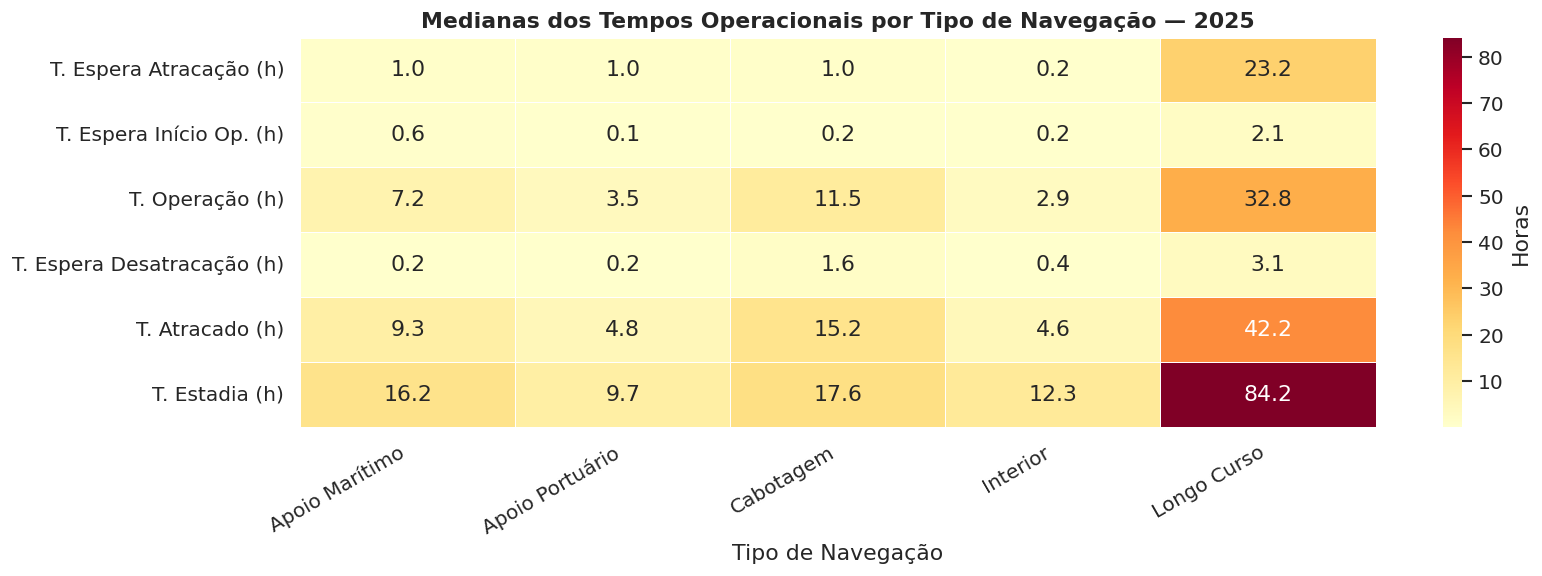

In [9]:
# Mediana dos KPIs de tempo por tipo de navegação
tempo_nav = (
    df.groupby('Tipo de Navegação da Atracação')[TEMPO_COLS]
    .median()
    .round(2)
)
tempo_nav.columns = [labels.get(c, c) for c in tempo_nav.columns]

print('Medianas (horas) por Tipo de Navegação:')
print(tempo_nav.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(tempo_nav.T, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Horas'})
ax.set_title('Medianas dos Tempos Operacionais por Tipo de Navegação — 2025', fontweight='bold')
ax.set_xlabel('Tipo de Navegação')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUT / 'nb08_06_heatmap_tempos_navegacao.png', bbox_inches='tight')
plt.show()

### 3.4 Top 15 Portos: Tempo Mediano de Espera e Estadia

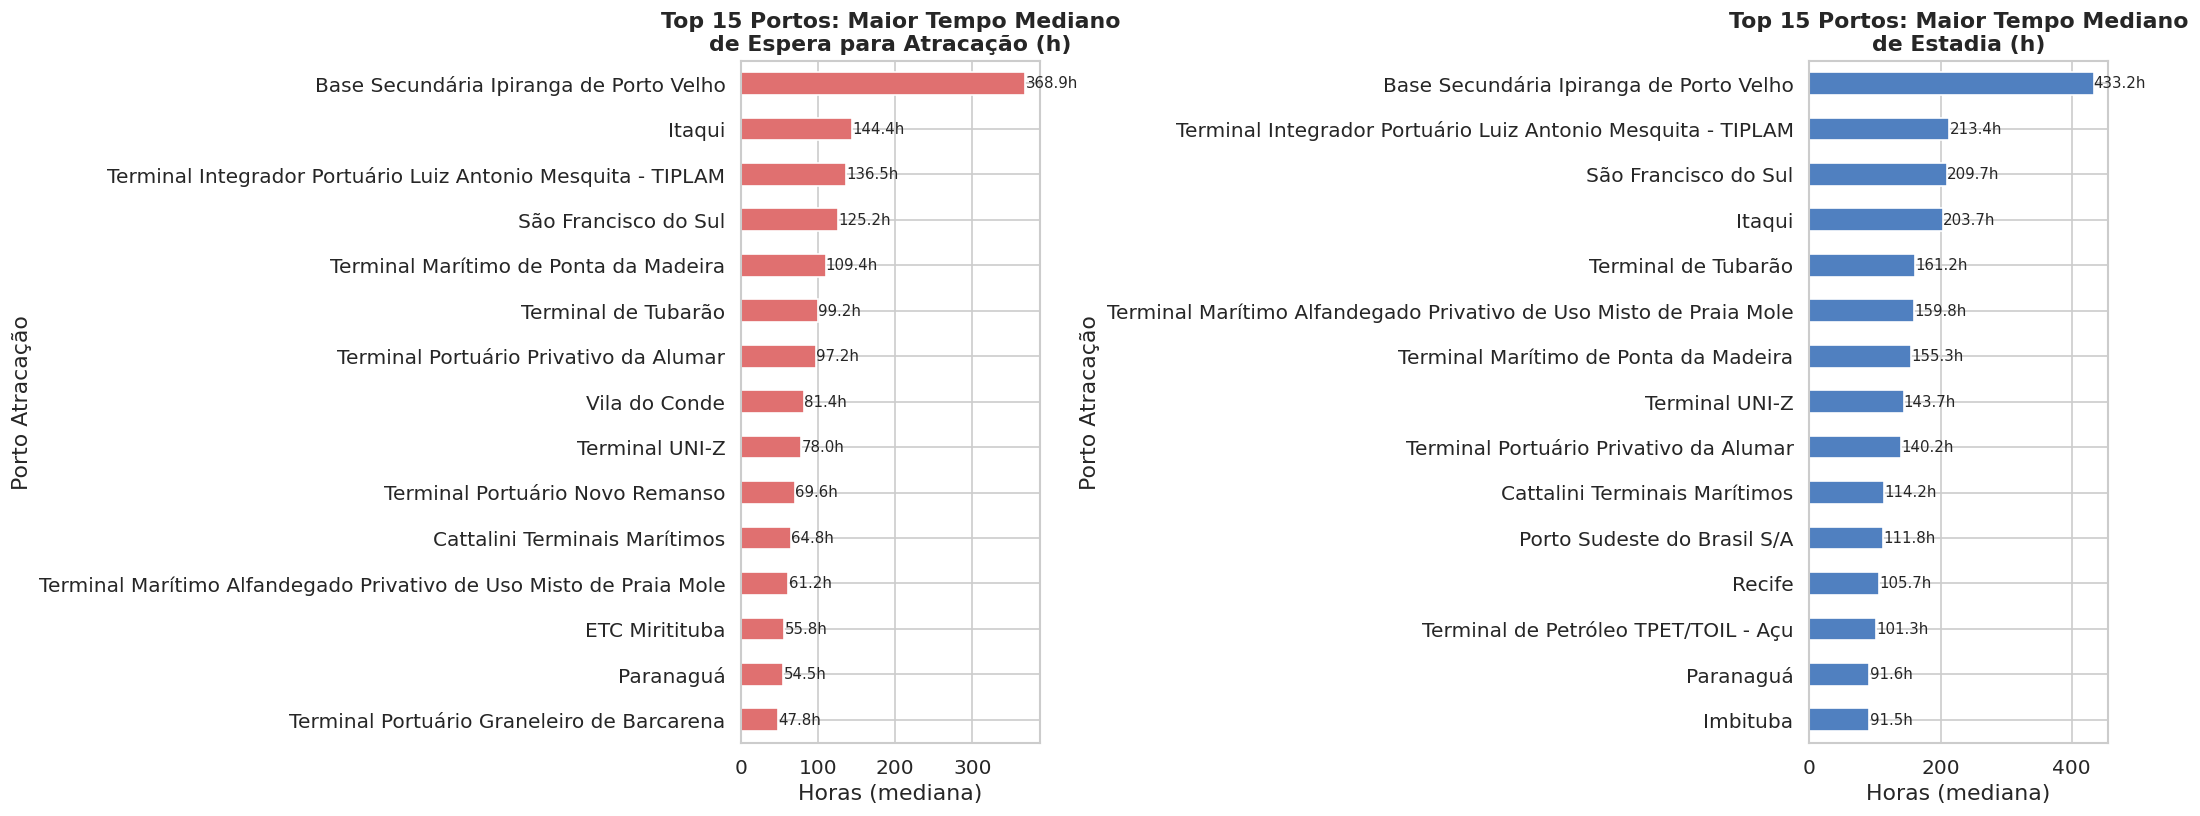

In [10]:
# Portos com >= 200 atracações
porto_counts = df['Porto Atracação'].value_counts()
portos_validos = porto_counts[porto_counts >= 200].index

porto_kpis = (
    df[df['Porto Atracação'].isin(portos_validos)]
    .groupby('Porto Atracação')[['TEsperaAtracacao','TEstadia','TOperacao']]
    .median()
    .round(1)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# T. Espera Atracação
top_espera = porto_kpis['TEsperaAtracacao'].sort_values(ascending=False).head(15)
top_espera.sort_values().plot.barh(ax=axes[0], color='#e07070')
axes[0].set_title('Top 15 Portos: Maior Tempo Mediano\nde Espera para Atracação (h)', fontweight='bold')
axes[0].set_xlabel('Horas (mediana)')
for i, v in enumerate(top_espera.sort_values().values):
    axes[0].text(v + 0.3, i, f'{v:.1f}h', va='center', fontsize=9)

# T. Estadia
top_estadia = porto_kpis['TEstadia'].sort_values(ascending=False).head(15)
top_estadia.sort_values().plot.barh(ax=axes[1], color='#5080c0')
axes[1].set_title('Top 15 Portos: Maior Tempo Mediano\nde Estadia (h)', fontweight='bold')
axes[1].set_xlabel('Horas (mediana)')
for i, v in enumerate(top_estadia.sort_values().values):
    axes[1].text(v + 0.3, i, f'{v:.1f}h', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'nb08_07_portos_tempos.png', bbox_inches='tight')
plt.show()

### 3.5 Eficiência: Razão TOperacao / TEstadia

Índice de Aproveitamento (TOperacao/TAtracado) por Tipo de Navegação:
                                Mediana (%)  Média (%)
Tipo de Navegação da Atracação                        
Cabotagem                              82.2       76.6
Interior                               80.2       69.8
Longo Curso                            85.1       80.0


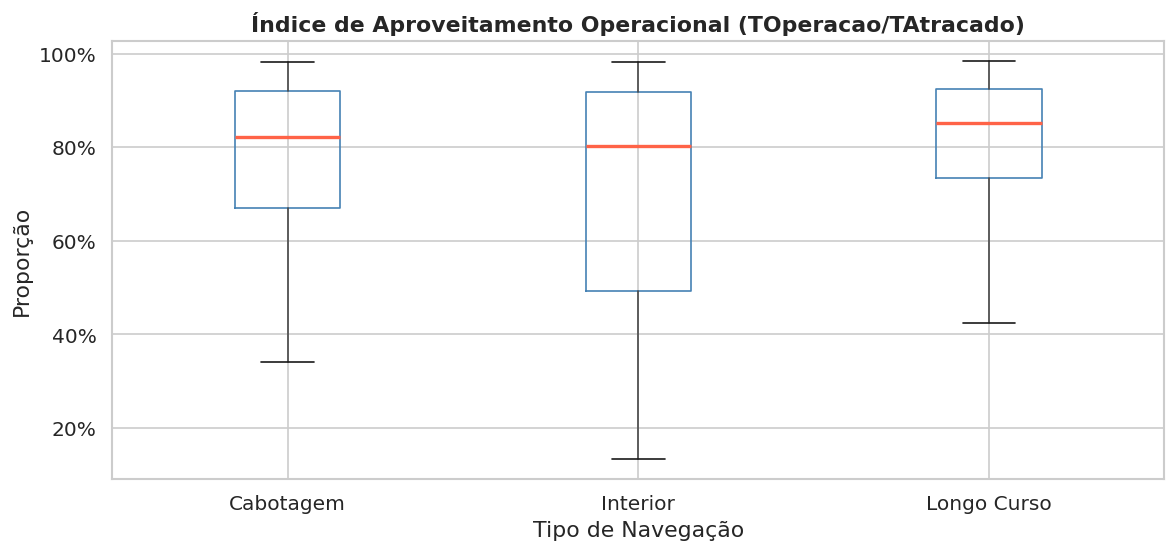

In [11]:
# Índice de aproveitamento = TOperacao / TAtracado
df['idx_aproveitamento'] = df['TOperacao'] / df['TAtracado']
df['idx_aproveitamento'] = df['idx_aproveitamento'].clip(0, 1)  # máximo 100%

# Por tipo de navegação
idx_nav = (
    df[df['Tipo de Navegação da Atracação'].isin(nav_interesse)]
    .groupby('Tipo de Navegação da Atracação')['idx_aproveitamento']
    .agg(['median','mean'])
    .mul(100)
    .round(1)
)
idx_nav.columns = ['Mediana (%)','Média (%)']
print('Índice de Aproveitamento (TOperacao/TAtracado) por Tipo de Navegação:')
print(idx_nav.to_string())

# Boxplot
fig, ax = plt.subplots(figsize=(10, 5))
subset_viz = df[df['Tipo de Navegação da Atracação'].isin(nav_interesse)].dropna(subset=['idx_aproveitamento'])
subset_viz.boxplot(column='idx_aproveitamento', by='Tipo de Navegação da Atracação',
                   ax=ax, whis=[5, 95], showfliers=False,
                   boxprops=dict(color='steelblue'),
                   medianprops=dict(color='tomato', linewidth=2))
ax.set_title('Índice de Aproveitamento Operacional (TOperacao/TAtracado)', fontweight='bold')
ax.set_xlabel('Tipo de Navegação')
ax.set_ylabel('Proporção')
plt.suptitle('')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(OUT / 'nb08_08_aproveitamento.png', bbox_inches='tight')
plt.show()

## 4. Análise de Paralisações

### 4.1 Top 20 Causas por Frequência e por Duração Total

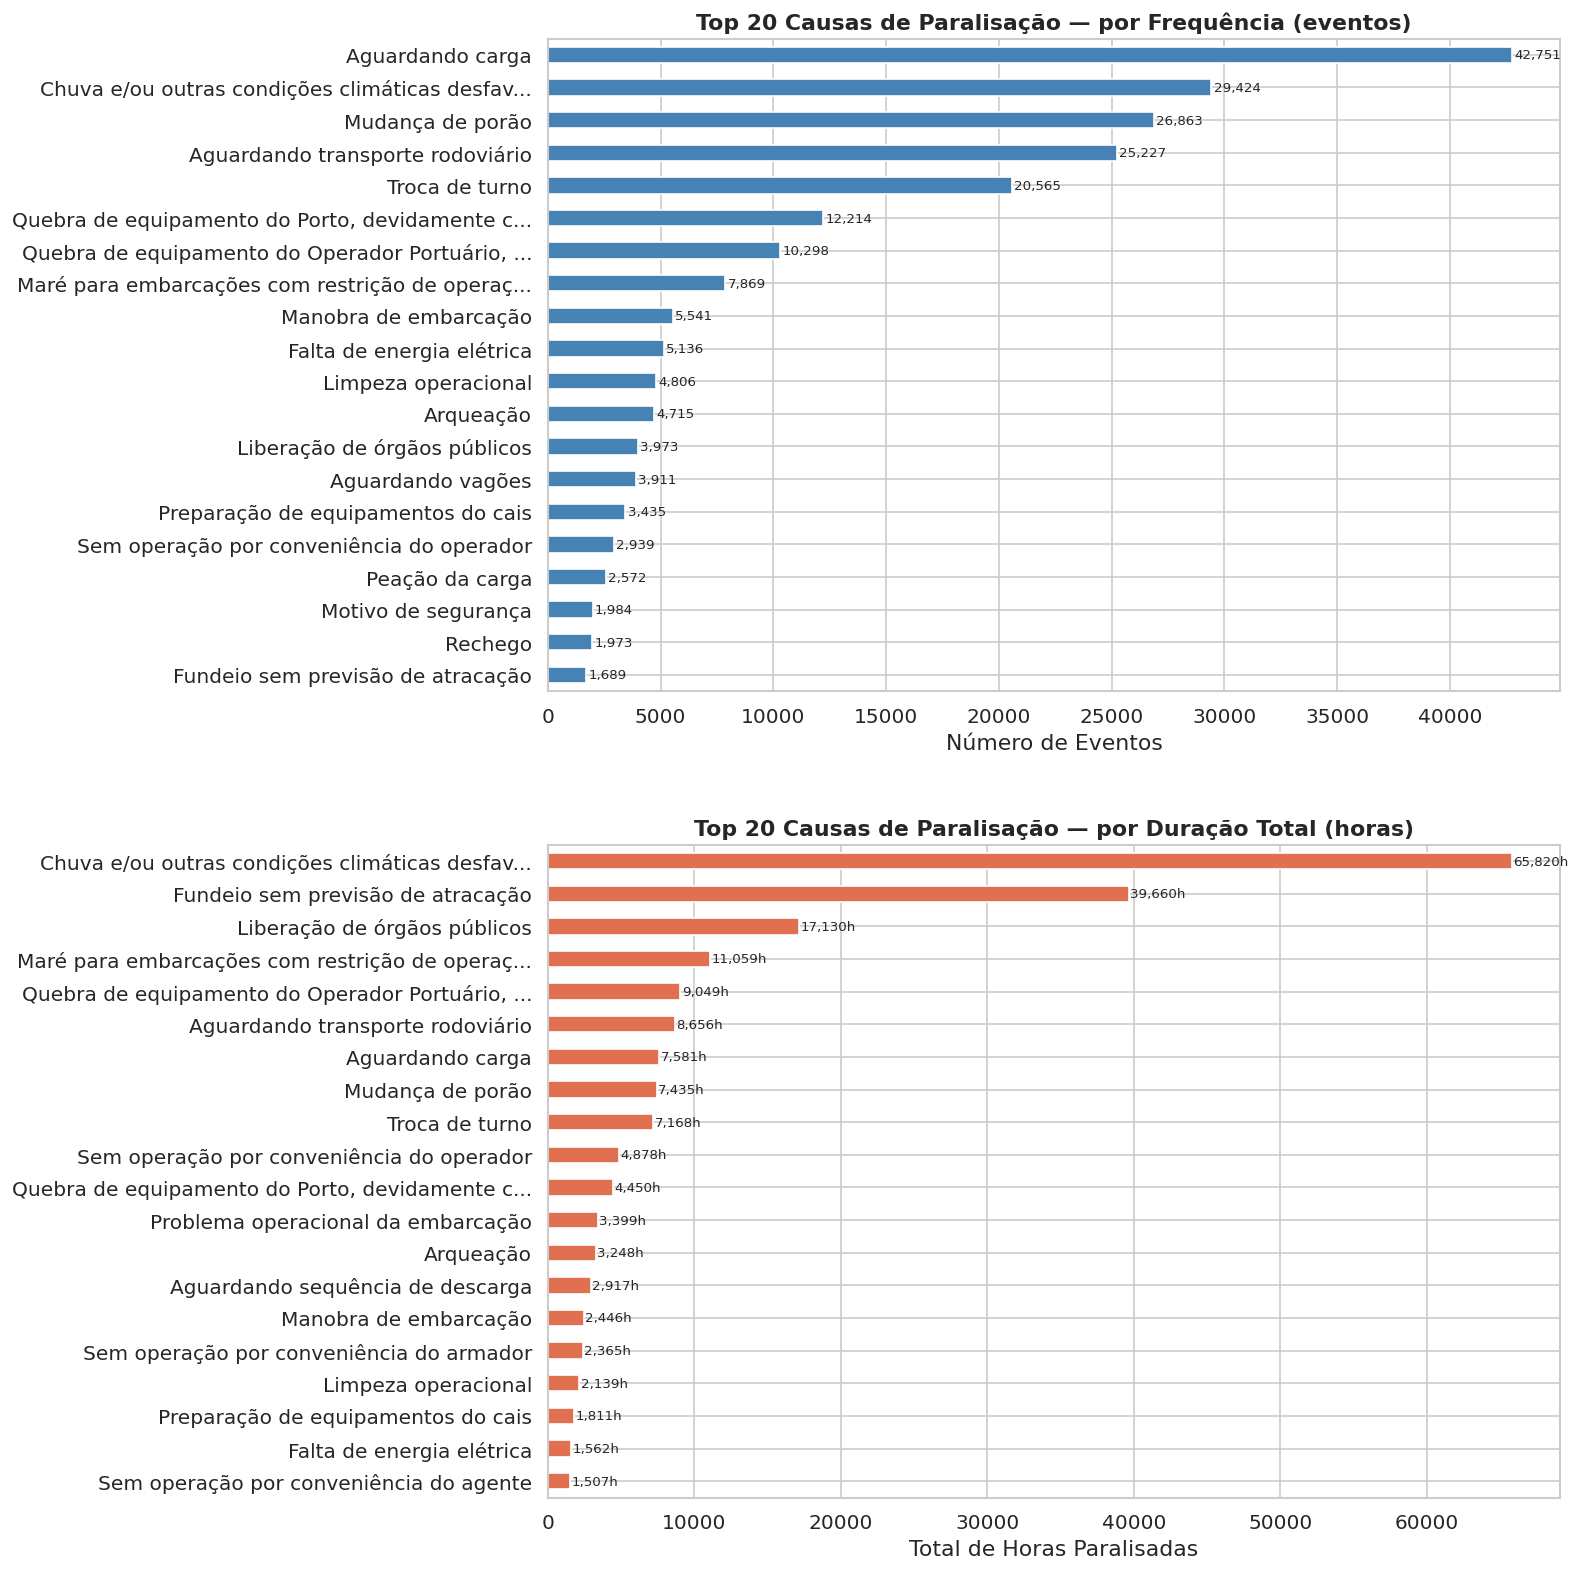

In [12]:
# Abreviar nomes longos
def abrev(s, n=45):
    return s[:n] + '...' if len(s) > n else s

causa_freq = p['DescricaoTempoDesconto'].value_counts().head(20)
causa_dur  = p.groupby('DescricaoTempoDesconto')['Duracao_h'].sum().sort_values(ascending=False).head(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Por frequência
causa_freq_plot = causa_freq.copy()
causa_freq_plot.index = [abrev(x) for x in causa_freq_plot.index]
causa_freq_plot.sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Causas de Paralisação — por Frequência (eventos)', fontweight='bold')
axes[0].set_xlabel('Número de Eventos')
for i, v in enumerate(causa_freq_plot.sort_values().values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=8)

# Por duração total
causa_dur_plot = causa_dur.copy()
causa_dur_plot.index = [abrev(x) for x in causa_dur_plot.index]
causa_dur_plot.sort_values().plot.barh(ax=axes[1], color='#e07050')
axes[1].set_title('Top 20 Causas de Paralisação — por Duração Total (horas)', fontweight='bold')
axes[1].set_xlabel('Total de Horas Paralisadas')
for i, v in enumerate(causa_dur_plot.sort_values().values):
    axes[1].text(v + 100, i, f'{v:,.0f}h', va='center', fontsize=8)

plt.tight_layout(pad=3)
plt.savefig(OUT / 'nb08_09_causas_paralisacao.png', bbox_inches='tight')
plt.show()

### 4.2 Duração Média por Causa (Top 15)

In [13]:
# Causas com >= 100 eventos
causa_stats = (
    p.groupby('DescricaoTempoDesconto')['Duracao_h']
    .agg(Eventos='count', TotalH='sum', MediaH='mean', MedianaH='median')
    .query('Eventos >= 100')
    .sort_values('TotalH', ascending=False)
)

print('Top 20 Causas de Paralisação (eventos >= 100):')
causa_stats.head(20).round(1)

Top 20 Causas de Paralisação (eventos >= 100):


,Eventos,TotalH,MediaH,MedianaH
DescricaoTempoDesconto,,,,
Chuva e/ou outras condições climáticas desfavoráveis,29424,65820.2,2.2,1.3
Fundeio sem previsão de atracação,1689,39659.5,23.5,0.6
Liberação de órgãos públicos,3973,17130.2,4.3,6.0
Maré para embarcações com restrição de operação,7869,11059.0,1.4,1.0
"Quebra de equipamento do Operador Portuário, devidamente comprovada",10298,9049.1,0.9,0.4
Aguardando transporte rodoviário,25227,8656.4,0.3,0.2
Aguardando carga,42751,7580.7,0.2,0.0
Mudança de porão,26863,7434.7,0.3,0.2
Troca de turno,20565,7168.5,0.3,0.2


Paralisações por Categoria — 2025:
                             Eventos   TotalH  Share_H (%)
Categoria                                                 
Condições Climáticas/Hidro     37293  76879.2         36.5
Outros                         45753  67989.0         32.3
Burocrático/Órgãos Públicos     3973  17130.2          8.1
Falha de Equipamento           31083  16872.5          8.0
Logística/Aguardo de Carga     71889  16595.4          7.9
Operacional/Rotina             35627  15001.4          7.1


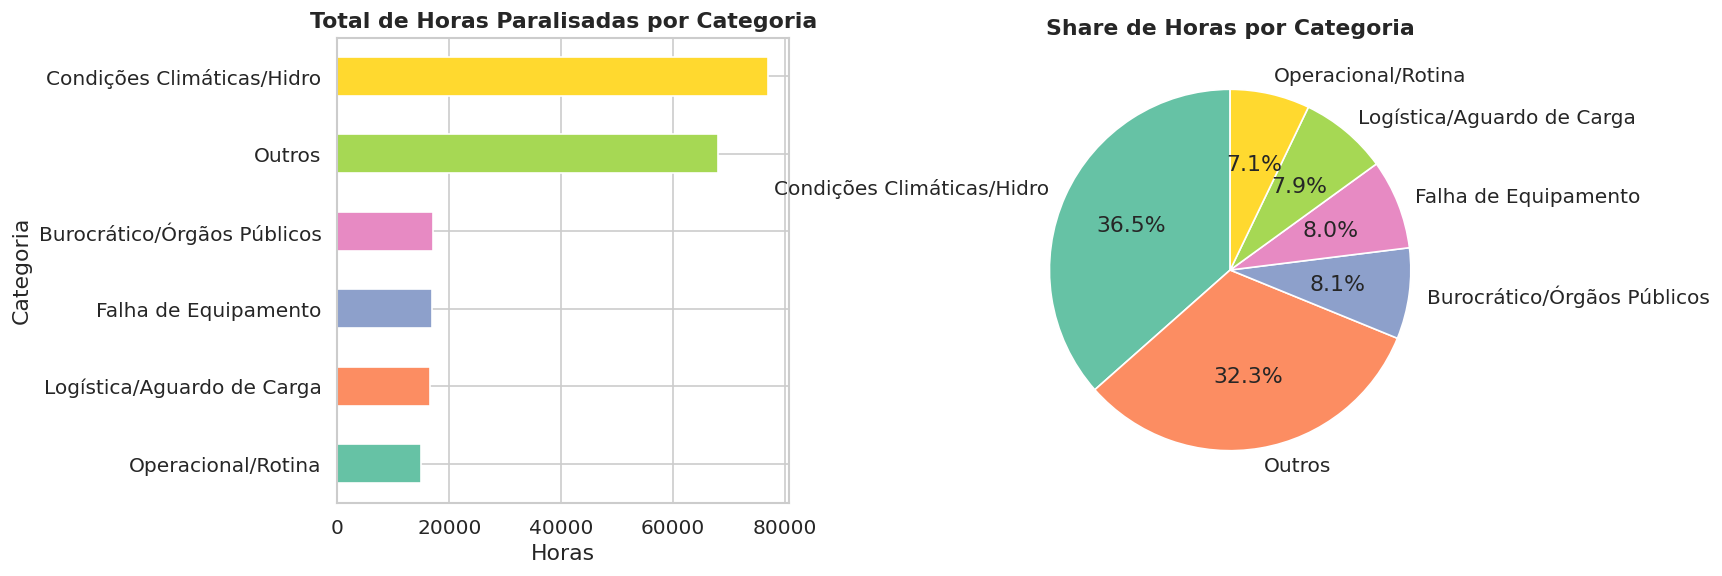

In [14]:
# Categorias de causa
def categorizar_causa(s):
    s = s.lower()
    if 'chuva' in s or 'clima' in s or 'maré' in s or 'vento' in s:
        return 'Condições Climáticas/Hidro'
    elif 'aguardando carga' in s or 'transporte rodoviário' in s or 'vagões' in s:
        return 'Logística/Aguardo de Carga'
    elif 'quebra' in s or 'equipamento' in s or 'falta de energia' in s:
        return 'Falha de Equipamento'
    elif 'turno' in s or 'preparação' in s or 'limpeza' in s or 'arqueação' in s or 'manobra' in s:
        return 'Operacional/Rotina'
    elif 'órgão' in s or 'inspeção' in s or 'liberação' in s or 'alfândega' in s:
        return 'Burocrático/Órgãos Públicos'
    else:
        return 'Outros'

p['Categoria'] = p['DescricaoTempoDesconto'].apply(categorizar_causa)

cat_stats = (
    p.groupby('Categoria')['Duracao_h']
    .agg(Eventos='count', TotalH='sum')
    .sort_values('TotalH', ascending=False)
)
cat_stats['Share_H (%)'] = (cat_stats['TotalH'] / cat_stats['TotalH'].sum() * 100).round(1)

print('Paralisações por Categoria — 2025:')
print(cat_stats.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_stats['TotalH'].sort_values().plot.barh(ax=axes[0],
    color=sns.color_palette('Set2', len(cat_stats)))
axes[0].set_title('Total de Horas Paralisadas por Categoria', fontweight='bold')
axes[0].set_xlabel('Horas')

axes[1].pie(cat_stats['TotalH'], labels=cat_stats.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2', len(cat_stats)),
            startangle=90)
axes[1].set_title('Share de Horas por Categoria', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'nb08_10_categorias_paralisacao.png', bbox_inches='tight')
plt.show()

### 4.3 Atracações com Maior Tempo Total de Paralisação

In [15]:
# Total de paralisação por atracação
paral_por_atr = (
    p.groupby('IDAtracacao')['Duracao_h']
    .agg(N_Eventos='count', Total_Paral_h='sum')
    .reset_index()
)

# Merge com atracação e tempos
df_full = df.merge(paral_por_atr, on='IDAtracacao', how='left')
df_full['Total_Paral_h'] = df_full['Total_Paral_h'].fillna(0)
df_full['N_Eventos']     = df_full['N_Eventos'].fillna(0).astype(int)

# Índice de paralisação = Total_Paral_h / TAtracado
df_full['idx_paralisacao'] = (df_full['Total_Paral_h'] / df_full['TAtracado']).clip(0, 1)

# Por tipo de navegação
idx_par_nav = (
    df_full[df_full['Tipo de Navegação da Atracação'].isin(nav_interesse)]
    .groupby('Tipo de Navegação da Atracação')['idx_paralisacao']
    .agg(Mediana='median', Media='mean')
    .mul(100)
    .round(1)
)
print('Índice de Paralisação Mediano (%) por Tipo de Navegação:')
print(idx_par_nav.to_string())

# Cobertura de paralisações
com_paral = (df_full['Total_Paral_h'] > 0).sum()
print(f'\nAtracações com pelo menos 1 evento de paralisação: {com_paral:,} ({com_paral/len(df_full)*100:.1f}%)')
print(f'Duração mediana de paralisação (quando > 0): {df_full[df_full["Total_Paral_h"]>0]["Total_Paral_h"].median():.1f}h')

Índice de Paralisação Mediano (%) por Tipo de Navegação:
                                Mediana  Media
Tipo de Navegação da Atracação                
Cabotagem                           0.0    2.5
Interior                            0.0    0.7
Longo Curso                         0.0    8.3

Atracações com pelo menos 1 evento de paralisação: 10,934 (9.4%)
Duração mediana de paralisação (quando > 0): 4.6h


## 5. KPI Summary Dashboard

In [16]:
# ── Tabela Resumo Final ────────────────────────────────────────────────────────
kpis_resumo = {
    'Total de Atracações 2025': f"{len(atr):,}",
    'Mês com maior volume': f"{atr['Mes'].value_counts().idxmax().upper()} ({atr['Mes'].value_counts().max():,})",
    'Share Interior': f"{nav['Interior']/nav.sum()*100:.1f}%",
    'Share Cabotagem': f"{nav['Cabotagem']/nav.sum()*100:.1f}%",
    'Share Longo Curso': f"{nav['Longo Curso']/nav.sum()*100:.1f}%",
    'Mediana T. Espera Atracação (h)': f"{df['TEsperaAtracacao'].median():.1f}",
    'Mediana T. Operação (h)': f"{df['TOperacao'].median():.1f}",
    'Mediana T. Atracado (h)': f"{df['TAtracado'].median():.1f}",
    'Mediana T. Estadia (h)': f"{df['TEstadia'].median():.1f}",
    'Atracações com paralisação (%)': f"{com_paral/len(df_full)*100:.1f}%",
    'Total eventos paralisação': f"{len(p):,}",
    'Top causa (frequência)': abrev(causa_freq.index[0]),
    'Top causa (horas totais)': abrev(causa_dur.index[0]),
}

kpis_df = pd.DataFrame.from_dict(kpis_resumo, orient='index', columns=['Valor'])
kpis_df.index.name = 'KPI'
print('=== KPI Summary — Operações Portuárias Brasil 2025 ===\n')
print(kpis_df.to_string())

=== KPI Summary — Operações Portuárias Brasil 2025 ===

                                                                            Valor
KPI                                                                              
Total de Atracações 2025                                                  116,098
Mês com maior volume                                                 JUL (10,538)
Share Interior                                                              46.6%
Share Cabotagem                                                             18.2%
Share Longo Curso                                                           19.6%
Mediana T. Espera Atracação (h)                                               1.0
Mediana T. Operação (h)                                                       6.8
Mediana T. Atracado (h)                                                      10.8
Mediana T. Estadia (h)                                                       19.7
Atracações com paralisação (%)            

## 6. Exportar Tabelas Processadas

In [17]:
PROC = Path('../outputs/processed_data')
PROC.mkdir(parents=True, exist_ok=True)

# KPI por porto
porto_kpis_full = (
    df_full[df_full['Porto Atracação'].isin(portos_validos)]
    .groupby('Porto Atracação').agg(
        Atracacoes=('IDAtracacao','count'),
        T_Espera_Median=('TEsperaAtracacao','median'),
        T_Operacao_Median=('TOperacao','median'),
        T_Atracado_Median=('TAtracado','median'),
        T_Estadia_Median=('TEstadia','median'),
        Paral_H_Total=('Total_Paral_h','sum'),
        Paral_H_Median=('Total_Paral_h','median'),
        Idx_Aproveitamento=('idx_aproveitamento','median'),
    )
    .round(2)
    .sort_values('Atracacoes', ascending=False)
)

porto_kpis_full.to_csv(PROC / 'kpis_operacionais_por_porto_2025.csv')
kpis_df.to_csv(PROC / 'kpi_summary_2025.csv')

print('Exportado: kpis_operacionais_por_porto_2025.csv')
print('Exportado: kpi_summary_2025.csv')
print(f'\nTop 10 portos por volume com KPIs:')
porto_kpis_full.head(10)[['Atracacoes','T_Espera_Median','T_Operacao_Median','T_Estadia_Median','Paral_H_Median','Idx_Aproveitamento']].round(1)

Exportado: kpis_operacionais_por_porto_2025.csv
Exportado: kpi_summary_2025.csv

Top 10 portos por volume com KPIs:


,Atracacoes,T_Espera_Median,T_Operacao_Median,T_Estadia_Median,Paral_H_Median,Idx_Aproveitamento
Porto Atracação,,,,,,
Brasil Logística Offshore e Estaleiro Naval,9861,0.5,6.8,10.5,0.0,0.9
Rio de Janeiro,5785,10.8,8.8,31.9,0.0,0.9
Belém,5545,0.4,0.7,1.4,0.0,0.7
Santos,5078,20.0,28.5,72.0,0.0,0.8
Santarém,4101,0.1,7.6,9.4,0.0,0.9
Terminal Graneleiro Hermasa,3192,42.2,2.6,50.4,0.0,0.9
Porto Gregório Curvo,2967,35.7,1.3,37.4,0.0,0.9
Hidrovias do Brasil Miritituba,2922,0.0,1.5,2.2,0.0,0.8
Terminal Vila do Conde,2897,0.1,2.7,4.2,0.0,0.7
